## **B. Text Structure Based Splitting / Recursive Character Based Splitting**

##### What is it?
- > Recursive chunking is the most recommended strategy in LangChain. It attempts to
split text hierarchically using a list of separators, starting with larger units (paragraphs)
and recursively moving to smaller units (sentences, then words) if chunks are still too
large.
- > Think of it as a smart scissors that tries to cut at natural boundaries - first trying
paragraph breaks, then sentence boundaries, and only cutting mid-sentence as a last
resort.


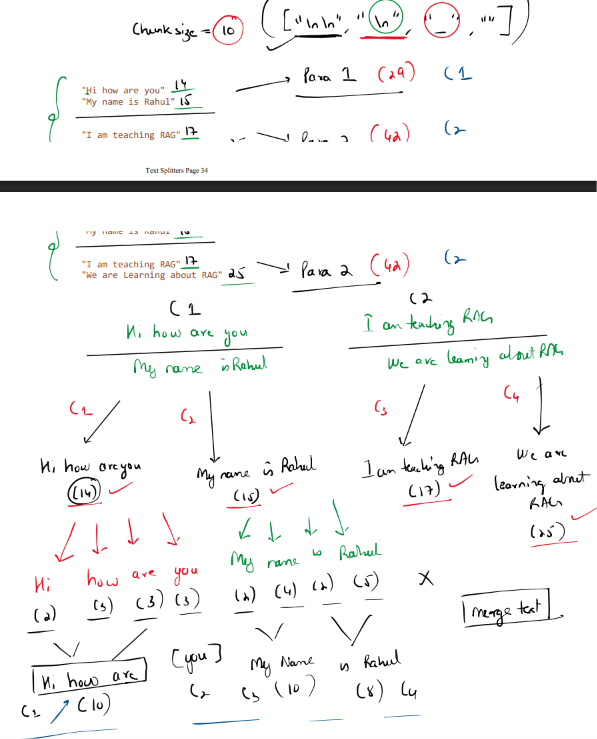


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text = """Hi how are you
My name is Rahul

I am teaching RAG
We are Learning about .RAG"""

print(text)

Hi how are you
My name is Rahul

I am teaching RAG
We are Learning about .RAG


In [3]:
splitter= RecursiveCharacterTextSplitter(
    chunk_size=10,
    chunk_overlap= 0
    # default separators = "\n\n", "\n", "_", ""   
)
splitter.split_text(text)

['Hi how are',
 'you',
 'My name',
 'is Rahul',
 'I am',
 'teaching',
 'RAG',
 'We are',
 'Learning',
 'about',
 '.RAG']

In [4]:
example_text = """Artificial intelligence is transforming technology and shaping the future.

Machine learning algorithms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of data efficiently.

Natural language processing has made significant strides in recent years.
Transformers architecture revolutionized the field in 2017.
Models like GPT and BERT have set new benchmarks.

Computer vision systems can now identify objects with remarkable accuracy.
Convolutional neural networks excel at image recognition tasks.
Self-driving cars rely heavily on advanced computer vision.

The impact of AI extends across multiple industries including healthcare, finance, and tra
Ethical considerations around AI development are becoming increasingly important.
Researchers are working on making AI systems more transparent and explainable. """

In [5]:
splitter= RecursiveCharacterTextSplitter(
    chunk_size= 150,
    chunk_overlap= 20             # 10-20 % of chunk size
)
chunks= splitter.split_text(example_text)
chunks

['Artificial intelligence is transforming technology and shaping the future.',
 'Machine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of data efficiently.',
 'Natural language processing has made significant strides in recent years.\nTransformers architecture revolutionized the field in 2017.',
 'Models like GPT and BERT have set new benchmarks.',
 'Computer vision systems can now identify objects with remarkable accuracy.\nConvolutional neural networks excel at image recognition tasks.',
 'Self-driving cars rely heavily on advanced computer vision.',
 'The impact of AI extends across multiple industries including healthcare, finance, and tra',
 'Ethical considerations around AI development are becoming increasingly important.',
 'Researchers are working on making AI systems more transparent and explainable.']

In [6]:
from termcolor import COLORS, colored
from random import choice

In [7]:
def display_chunks( chunks: list[str], overlap: int):
    print(f"Total number of Chunks: {len(chunks)}")
    length= [len(l) for l in chunks]
    print(f"Total Characters in the Chunks: {sum(length)},\n")

    colors_list= list(COLORS.keys())[2:8]
    for num, chunk in enumerate(chunks, 1):
        print(f"Chunk {num}: Length of Chunk: {len(chunk)}")
        print(colored(text= chunk, color= choice(colors_list)), end="\n\n")
        
display_chunks(chunks, 0)

Total number of Chunks: 9
Total Characters in the Chunks: 843,

Chunk 1: Length of Chunk: 74
Artificial intelligence is transforming technology and shaping the future.

Chunk 2: Length of Chunk: 141
Machine learning algorithms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of data efficiently.

Chunk 3: Length of Chunk: 133
Natural language processing has made significant strides in recent years.
Transformers architecture revolutionized the field in 2017.

Chunk 4: Length of Chunk: 49
Models like GPT and BERT have set new benchmarks.

Chunk 5: Length of Chunk: 138
Computer vision systems can now identify objects with remarkable accuracy.
Convolutional neural networks excel at image recognition tasks.

Chunk 6: Length of Chunk: 59
Self-driving cars rely heavily on advanced computer vision.

Chunk 7: Length of Chunk: 90
The impact of AI extends across multiple industries including healthcare, finance, and tra

Chunk 8: Length of Chunk: 81
Eth

### Documents

In [8]:
from langchain_core.documents import Document

list_of_text= [text, example_text]           # combining 2 text document objects in a single list
docs= [ Document( page_content= text ) for text in list_of_text ]
[doc.page_content for doc in docs]

['Hi how are you\nMy name is Rahul\n\nI am teaching RAG\nWe are Learning about .RAG',
 'Artificial intelligence is transforming technology and shaping the future.\n\nMachine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of data efficiently.\n\nNatural language processing has made significant strides in recent years.\nTransformers architecture revolutionized the field in 2017.\nModels like GPT and BERT have set new benchmarks.\n\nComputer vision systems can now identify objects with remarkable accuracy.\nConvolutional neural networks excel at image recognition tasks.\nSelf-driving cars rely heavily on advanced computer vision.\n\nThe impact of AI extends across multiple industries including healthcare, finance, and tra\nEthical considerations around AI development are becoming increasingly important.\nResearchers are working on making AI systems more transparent and explainable. ']

In [10]:
doc_chunks= splitter.split_documents(docs)
print("Number of chunks:",len(doc_chunks))
[doc_chunk.page_content for doc_chunk in doc_chunks]

Number of chunks: 10


['Hi how are you\nMy name is Rahul\n\nI am teaching RAG\nWe are Learning about .RAG',
 'Artificial intelligence is transforming technology and shaping the future.',
 'Machine learning algorithms are becoming more sophisticated every day.\nDeep learning models can now process vast amounts of data efficiently.',
 'Natural language processing has made significant strides in recent years.\nTransformers architecture revolutionized the field in 2017.',
 'Models like GPT and BERT have set new benchmarks.',
 'Computer vision systems can now identify objects with remarkable accuracy.\nConvolutional neural networks excel at image recognition tasks.',
 'Self-driving cars rely heavily on advanced computer vision.',
 'The impact of AI extends across multiple industries including healthcare, finance, and tra',
 'Ethical considerations around AI development are becoming increasingly important.',
 'Researchers are working on making AI systems more transparent and explainable.']

#### Advantages:
-  Best balance between chunk size and semantic coherence
-  Preserves natural language structure
-  Respects document hierarchy (paragraphs > sentences -> words)
-  Recommended for most use cases
-  Configurable separators for different document types
-  Maintains context better than fixed-size chunking

#### Disadvantages:
-  More complex than simple fixed-size splitting
-  May still break semantic units if they're too long
-  Requires careful separator selection (different seperators for markdown, html , python, etc.)
-  Can create variable chunk sizes
-  May not work well with highly structured documents